In [13]:
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml
import re


def resolve_project_root() -> Path:
    """Возвращает корень проекта для запуска из notebooks или из корня."""
    root = Path.cwd()
    if not (root / "results").exists() and (root.parent / "results").exists():
        root = root.parent
    return root


def load_wgan_histories(results_dir: Path) -> pd.DataFrame:
    """Считывает историю обучения из новой и старой структуры results."""
    frames = []
    for first_level_dir in sorted(results_dir.iterdir()):
        if not first_level_dir.is_dir():
            continue

        legacy_history_path = first_level_dir / "wgan_training_history.csv"
        if legacy_history_path.exists():
            run_df = pd.read_csv(legacy_history_path)
            if "epoch" in run_df.columns:
                run_df["run_name"] = "legacy"
                run_df["config"] = first_level_dir.name
                run_df["run_id"] = first_level_dir.name
                if "global_step" not in run_df.columns:
                    run_df["global_step"] = run_df["epoch"]
                frames.append(run_df)
            continue

        for config_dir in sorted(first_level_dir.iterdir()):
            if not config_dir.is_dir():
                continue
            history_path = config_dir / "wgan_training_history.csv"
            if not history_path.exists():
                continue
            run_df = pd.read_csv(history_path)
            if "epoch" not in run_df.columns:
                continue
            run_df["run_name"] = first_level_dir.name
            run_df["config"] = config_dir.name
            run_df["run_id"] = f"{first_level_dir.name}/{config_dir.name}"
            if "global_step" not in run_df.columns:
                run_df["global_step"] = run_df["epoch"]
            frames.append(run_df)

    if not frames:
        raise FileNotFoundError(f"Не найдены файлы wgan_training_history.csv в {results_dir}")

    df = pd.concat(frames, ignore_index=True)
    df = df.sort_values(["run_id", "epoch"]).reset_index(drop=True)
    return df


def plot_metric_by_epoch(
    metric: str,
    result_subdir: str,
    runs: Optional[Iterable[str]] = None,
    run_names: Optional[Iterable[str]] = None,
    results_dir: Optional[Path] = None,
    x_axis: str = "epoch",
    figsize=(12, 6),
    optimize: str = "min",
):
    """Строит зависимость метрики от эпохи/шага и печатает лучшее значение метрики."""
    if x_axis not in {"epoch", "global_step"}:
        raise ValueError("x_axis должен быть 'epoch' или 'global_step'")
    if optimize not in {"min", "max"}:
        raise ValueError("optimize должен быть 'min' или 'max'")

    project_root = resolve_project_root()
    if results_dir is None:
        base_results_dir = project_root / "results"
        if result_subdir is not None:
            base_results_dir = base_results_dir / result_subdir
    else:
        base_results_dir = results_dir
    df = load_wgan_histories(base_results_dir)

    metric_columns = [col for col in df.columns if col not in {"epoch", "global_step", "run_name", "config", "run_id"}]
    if metric not in metric_columns:
        raise ValueError(f"Метрика '{metric}' не найдена. Доступные: {metric_columns}")

    if run_names is not None:
        run_names = list(run_names)
        df = df[df["run_name"].isin(run_names)].copy()
        if df.empty:
            raise ValueError(f"Для run_names={run_names} не найдено данных")

    if runs is not None:
        runs = list(runs)
        df = df[df["run_id"].isin(runs)].copy()
        if df.empty:
            raise ValueError(f"Для runs={runs} не найдено данных")

    plt.figure(figsize=figsize)
    sns.lineplot(data=df, x=x_axis, y=metric, hue="run_id", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title("RMSE by Epoch")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    best_idx = df[metric].idxmin() if optimize == "min" else df[metric].idxmax()
    best_row = df.loc[best_idx]
    print(
        f"Best ({optimize}) {metric}: {best_row[metric]:.6f} | "
        f"run={best_row['run_id']} | {x_axis}={best_row[x_axis]}"
    )


def extract_param_from_config(config_path: Path, param_name: str) -> Optional[float]:
    """Извлекает значение параметра из конфига."""
    try:
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        
        if param_name == "n_events":
            return float(config.get("aging", {}).get("n_events"))
        elif param_name == "batch_size":
            return float(config.get("wgan_params", {}).get("batch_size"))
        elif param_name == "epochs":
            return float(config.get("wgan_params", {}).get("epochs"))
        elif param_name == "lr":
            return float(config.get("wgan_params", {}).get("lr"))
        elif param_name == "gp_lambda":
            return float(config.get("wgan_params", {}).get("gp_lambda"))
        else:
            def find_in_dict(d, key):
                if key in d:
                    return d[key]
                for v in d.values():
                    if isinstance(v, dict):
                        result = find_in_dict(v, key)
                        if result is not None:
                            return result
                return None
            
            result = find_in_dict(config, param_name)
            if result is not None:
                return float(result)
    except Exception as e:
        pass
    
    config_name = config_path.stem
    if param_name == "n_events":
        match = re.search(r'n(\d+)', config_name)
        if match:
            return float(match.group(1))
    elif param_name == "batch_size":
        match = re.search(r'b(\d+)', config_name)
        if match:
            return float(match.group(1))
    
    return None


def plot_best_metric_vs_param(
    metric: str,
    run_dir: str,
    param_name: str = "n_events",
    optimize: str = "min",
    results_dir: Optional[Path] = None,
    experiment_name: Optional[str] = None,
    figsize=(10, 6),
    exclude_param_values: Optional[Iterable[float]] = None,
    baseline_point: Optional[tuple] = None,
):
    """Строит график лучшей метрики в зависимости от параметра конфига.
    
    Args:
        metric: Название метрики (например, "W_rmse")
        run_dir: Директория запуска (например, "run_n_events")
        param_name: Название параметра для оси X (по умолчанию "n_events")
        optimize: "min" или "max" - что оптимизируем
        results_dir: Опциональный путь к results (если None, берется из project_root)
        experiment_name: Опциональное имя эксперимента (если None, берется из структуры)
        figsize: Размер графика
        exclude_param_values: Значения param_name, которые нужно исключить с графика
        baseline_point: Опциональная точка (x, y) для отображения baseline на графике
    """
    if optimize not in {"min", "max"}:
        raise ValueError("optimize должен быть 'min' или 'max'")
    
    project_root = resolve_project_root()
    if results_dir is None:
        base_results_dir = project_root / "results" / run_dir
    else:
        base_results_dir = results_dir / run_dir
    
    if not base_results_dir.exists():
        raise FileNotFoundError(f"Директория {base_results_dir} не найдена")
    
    df = load_wgan_histories(base_results_dir)
    
    metric_columns = [col for col in df.columns if col not in {"epoch", "global_step", "run_name", "config", "run_id"}]
    if metric not in metric_columns:
        raise ValueError(f"Метрика '{metric}' не найдена. Доступные: {metric_columns}")
    
    best_by_config = []
    
    for config_name in df["config"].unique():
        config_df = df[df["config"] == config_name].copy()
        if config_df.empty:
            continue
        
        best_idx = config_df[metric].idxmin() if optimize == "min" else config_df[metric].idxmax()
        best_row = config_df.loc[best_idx]
        
        config_path = None
        if experiment_name:
            config_path = project_root / "configs" / "generated" / experiment_name / f"{config_name}.yaml"
        else:
            found_exp_name = None
            for exp_dir in base_results_dir.iterdir():
                if exp_dir.is_dir() and (exp_dir / config_name).is_dir():
                    found_exp_name = exp_dir.name
                    break
            
            if found_exp_name:
                config_path = project_root / "configs" / "generated" / found_exp_name / f"{config_name}.yaml"
        
        if config_path is None or not config_path.exists():
            for gen_dir in (project_root / "configs" / "generated").iterdir():
                if gen_dir.is_dir():
                    potential_path = gen_dir / f"{config_name}.yaml"
                    if potential_path.exists():
                        config_path = potential_path
                        break
        
        param_value = None
        if config_path and config_path.exists():
            param_value = extract_param_from_config(config_path, param_name)
        
        if param_value is not None:
            best_by_config.append({
                "config": config_name,
                "param_value": param_value,
                "best_metric": best_row[metric],
                "epoch": best_row["epoch"],
            })
    
    if not best_by_config:
        raise ValueError(f"Не удалось извлечь параметр '{param_name}' ни для одного конфига")
    
    best_df = pd.DataFrame(best_by_config)
    best_df = best_df.sort_values("param_value")

    if exclude_param_values is not None:
        excluded = set(float(v) for v in exclude_param_values)
        best_df = best_df[~best_df["param_value"].isin(excluded)].copy()

    if best_df.empty:
        raise ValueError("После фильтрации не осталось данных для построения графика")

    if baseline_point is not None:
        import numpy as np
        xs = np.concatenate([[baseline_point[0]], best_df["param_value"].values])
        ys = np.concatenate([[baseline_point[1]], best_df["best_metric"].values])
        sort_idx = np.argsort(xs)
        xs, ys = xs[sort_idx], ys[sort_idx]
    else:
        xs, ys = best_df["param_value"].values, best_df["best_metric"].values

    plt.figure(figsize=figsize)
    plt.plot(xs, ys, marker="o", linewidth=2, markersize=8)
    plt.xlabel(f"{param_name}")
    plt.ylabel("RMSE")
    plt.title(f"RMSE VS {param_name}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    best_overall_idx = best_df["best_metric"].idxmin() if optimize == "min" else best_df["best_metric"].idxmax()
    best_overall = best_df.loc[best_overall_idx]
    print(
        f"Best overall ({optimize}) {metric}: {best_overall['best_metric']:.6f} | "
        f"{param_name}={best_overall['param_value']} | config={best_overall['config']}"
    )

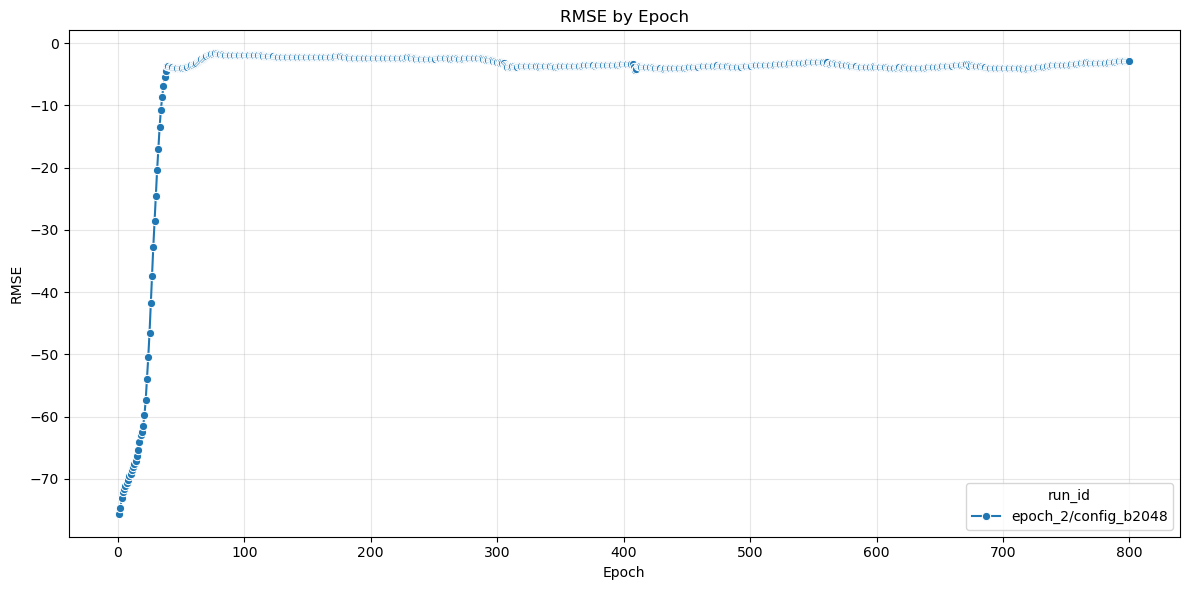

Best (min) W_r2: -75.604164 | run=epoch_2/config_b2048 | epoch=1


In [ ]:
plot_metric_by_epoch(metric="W_r2", result_subdir="run_20260226_111611", x_axis="epoch")

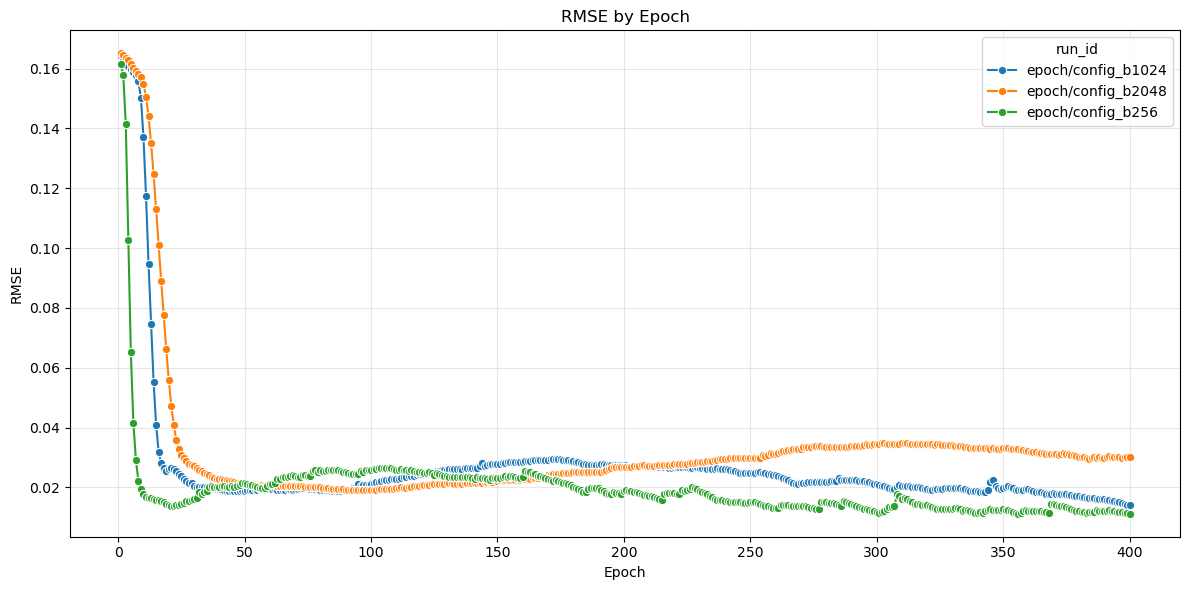

Best (min) W_rmse: 0.011192 | run=epoch/config_b256 | epoch=400


In [ ]:
plot_metric_by_epoch(metric="W_rmse", result_subdir="run_20260223_102504", x_axis="epoch")

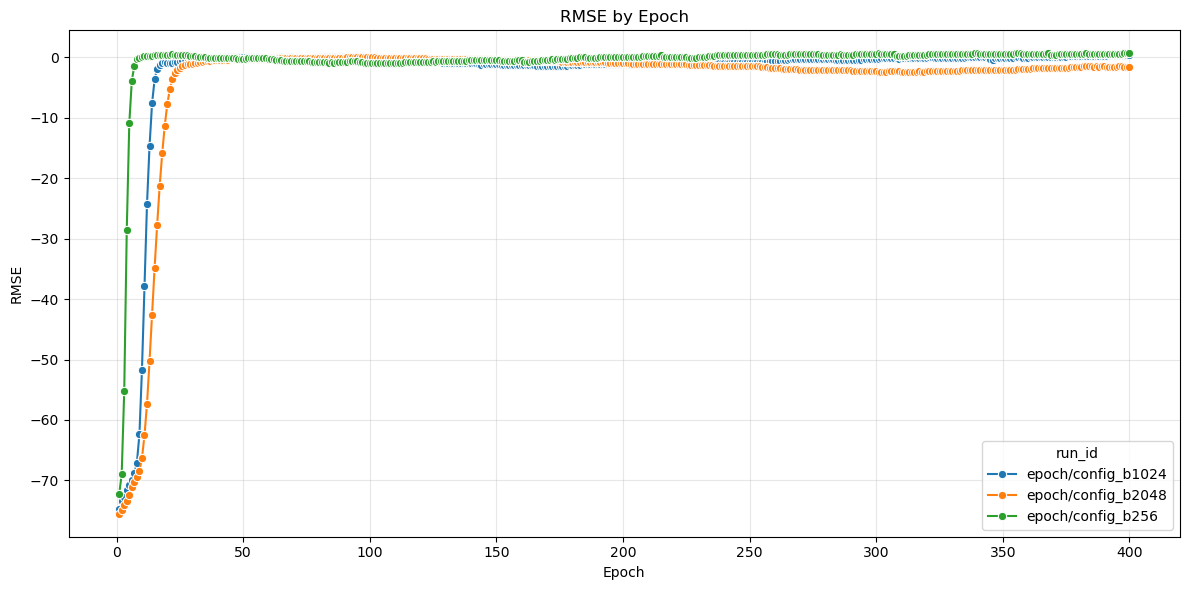

Best (min) W_r2: -75.502487 | run=epoch/config_b2048 | epoch=1


In [ ]:
plot_metric_by_epoch(metric="W_r2", result_subdir="run_20260223_102504", x_axis="epoch")

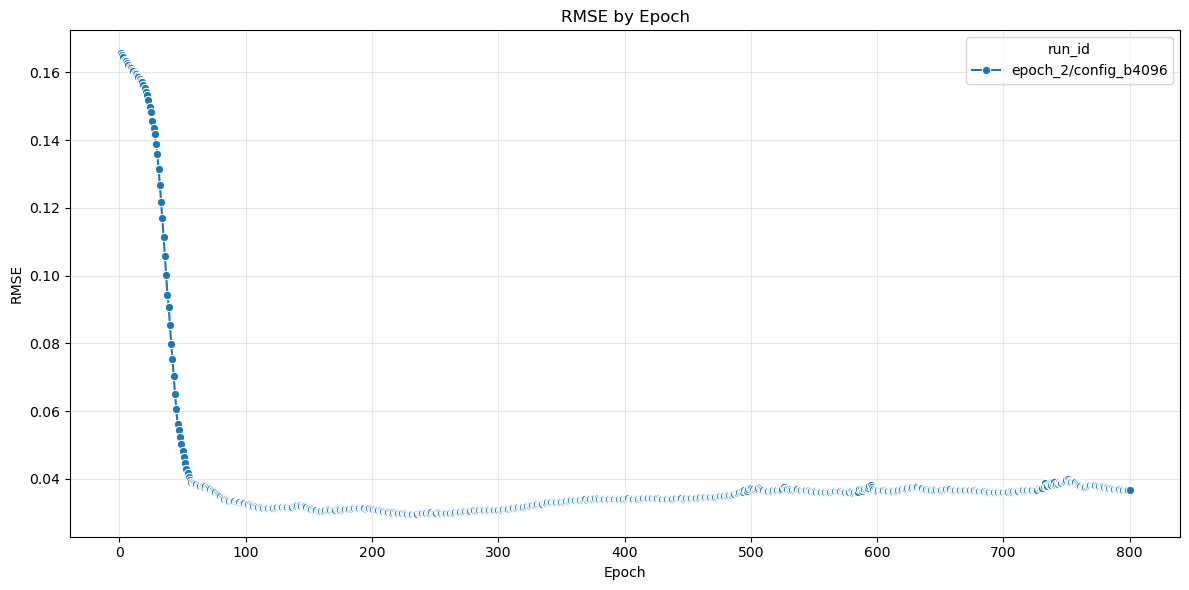

Best (min) W_rmse: 0.029703 | run=epoch_2/config_b4096 | epoch=231


In [ ]:
plot_metric_by_epoch(metric="W_rmse", result_subdir="run_20260227_165325", x_axis="epoch")

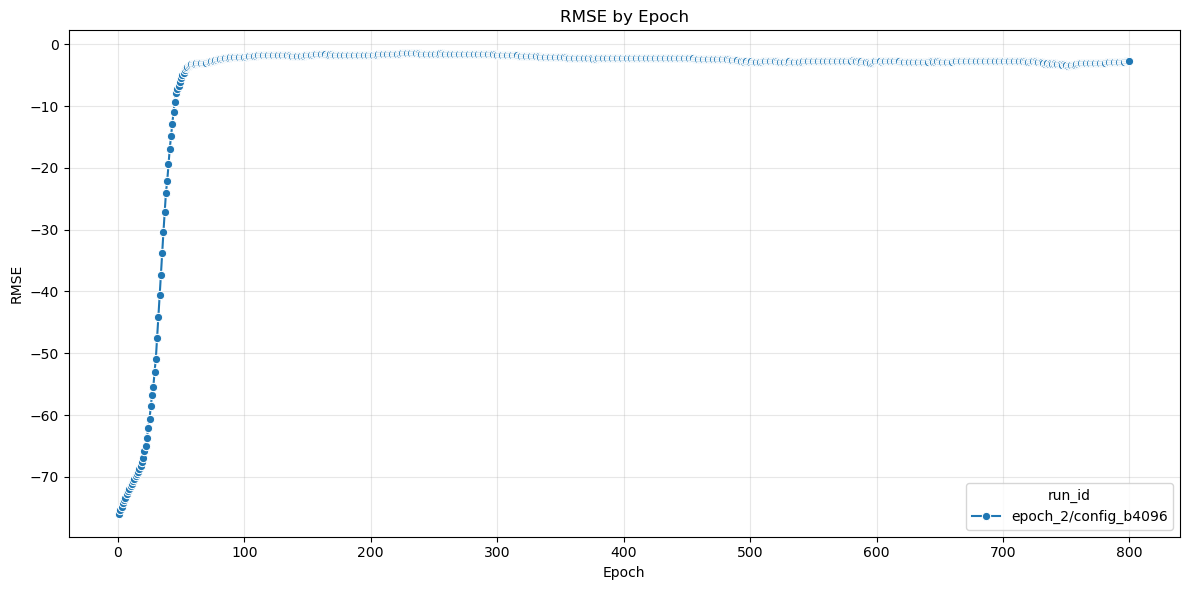

Best (min) W_r2: -75.948730 | run=epoch_2/config_b4096 | epoch=1


In [ ]:
plot_metric_by_epoch(metric="W_r2", result_subdir="run_20260227_165325", x_axis="epoch")

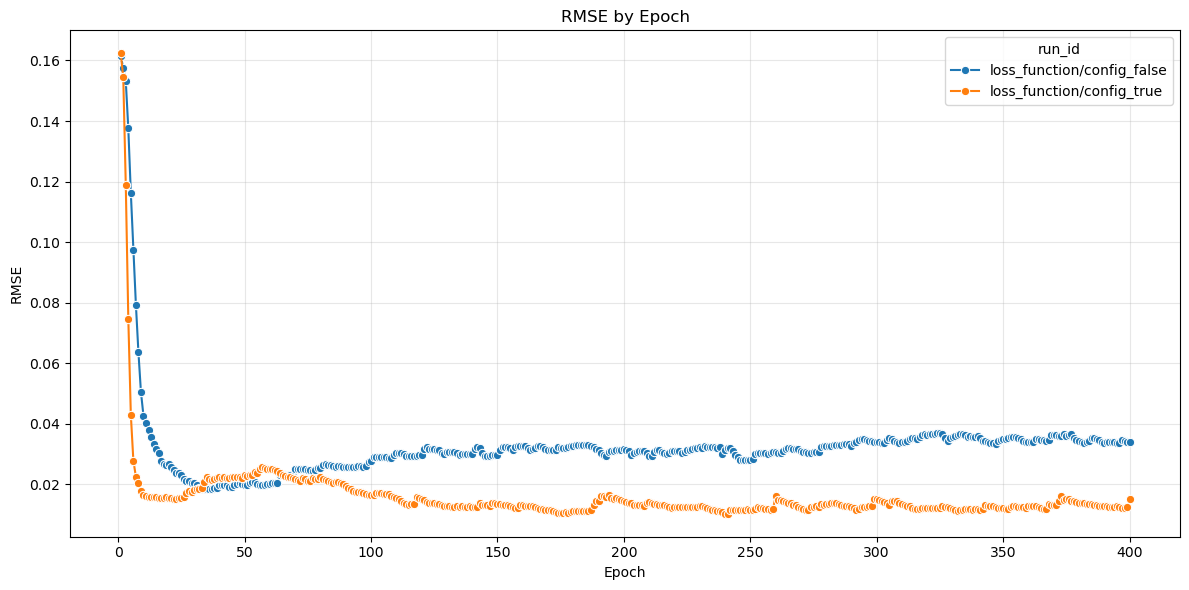

Best (min) W_rmse: 0.010333 | run=loss_function/config_true | epoch=240


In [ ]:
plot_metric_by_epoch(metric="W_rmse", result_subdir="run_20260228_152206", x_axis="epoch")

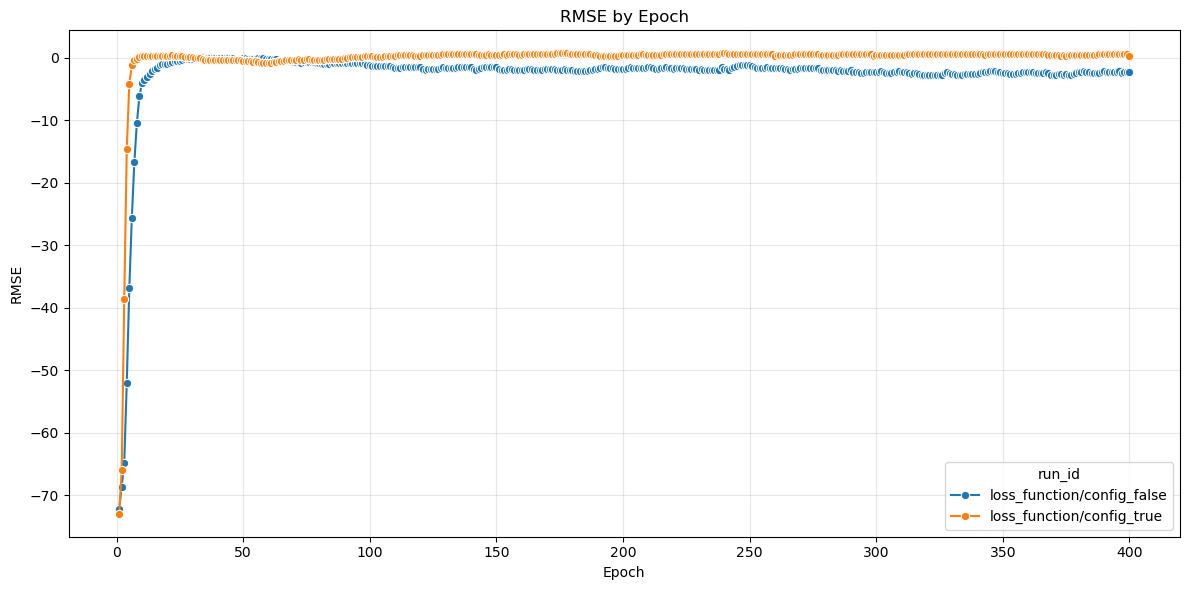

Best (min) W_r2: -72.954781 | run=loss_function/config_true | epoch=1


In [ ]:
plot_metric_by_epoch(metric="W_r2", result_subdir="run_20260228_152206", x_axis="epoch")

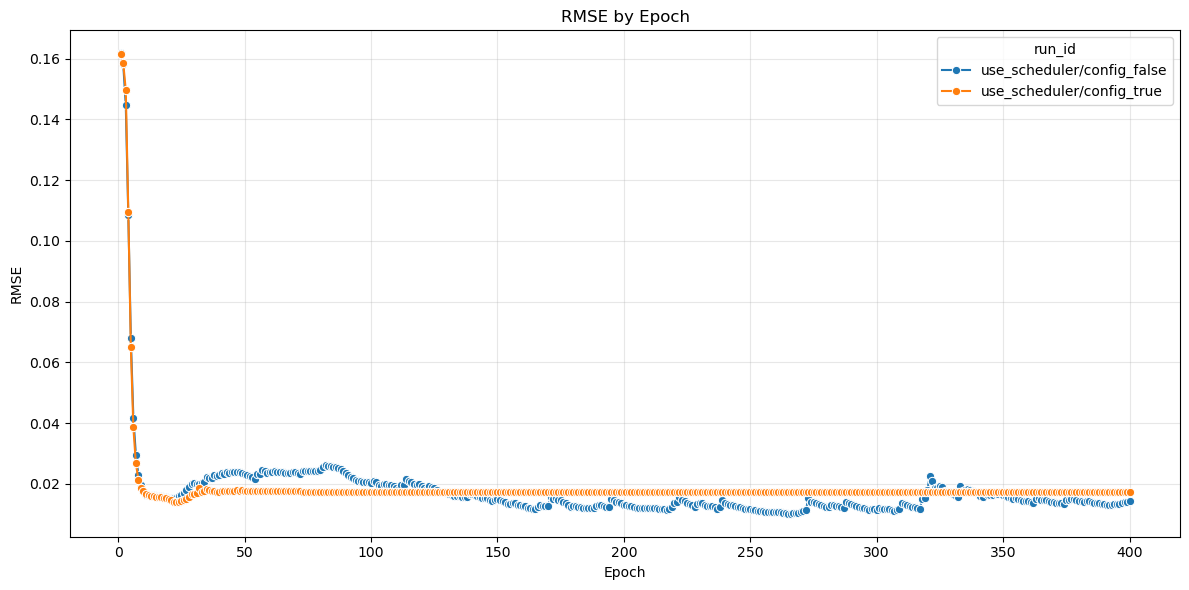

Best (min) W_rmse: 0.010199 | run=use_scheduler/config_false | epoch=266


In [ ]:
plot_metric_by_epoch(metric="W_rmse", result_subdir="run_20260301_125129", x_axis="epoch")

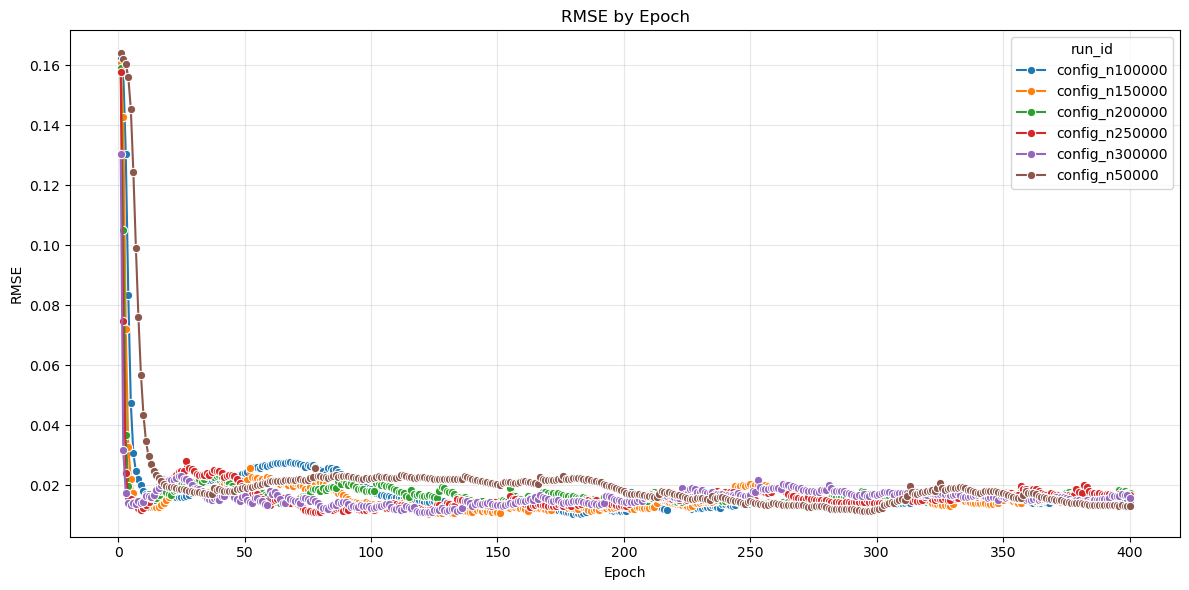

Best (min) W_rmse: 0.010604 | run=config_n150000 | epoch=123


In [ ]:
plot_metric_by_epoch(metric="W_rmse", result_subdir="run_n_events/n_events", x_axis="epoch")

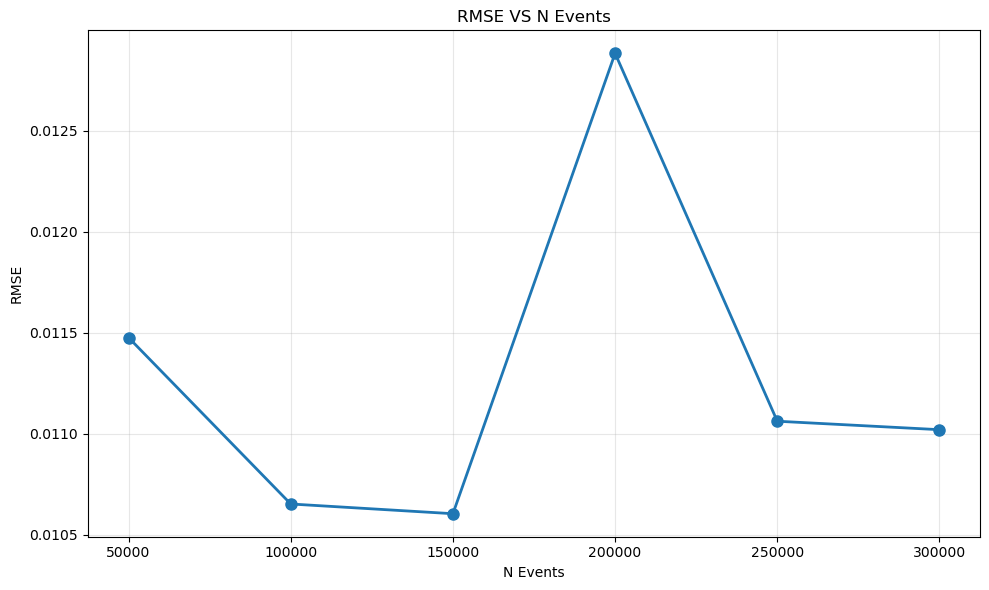

Best overall (min) W_rmse: 0.010604 | n_events=150000.0 | config=config_n150000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_n_events",
    param_name="n_events",
    optimize="min",
    experiment_name="n_events"
)

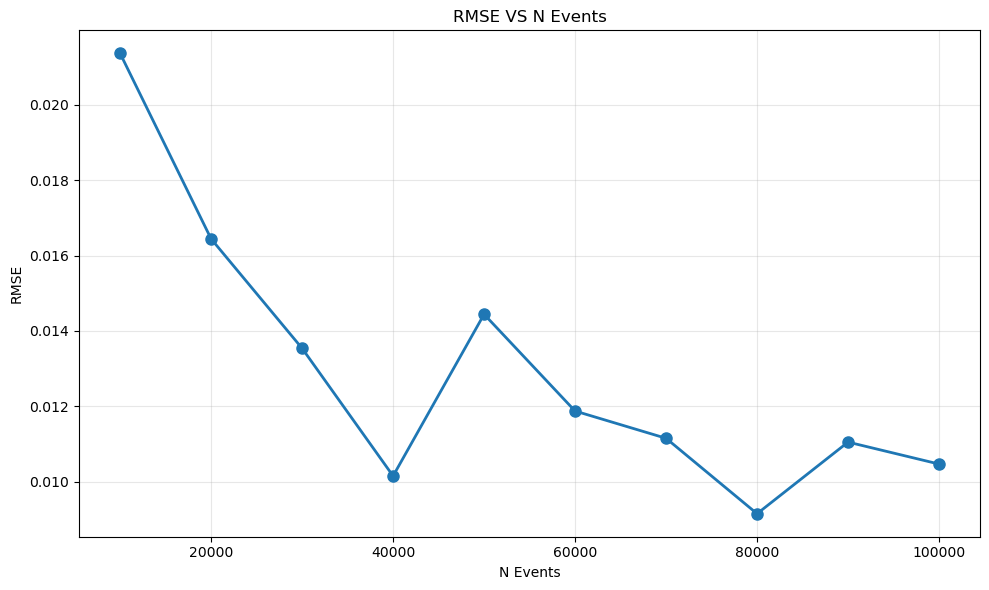

Best overall (min) W_rmse: 0.009148 | n_events=80000.0 | config=config_n80000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_n_events_2",
    param_name="n_events",
    optimize="min",
    experiment_name="n_events_2"
)

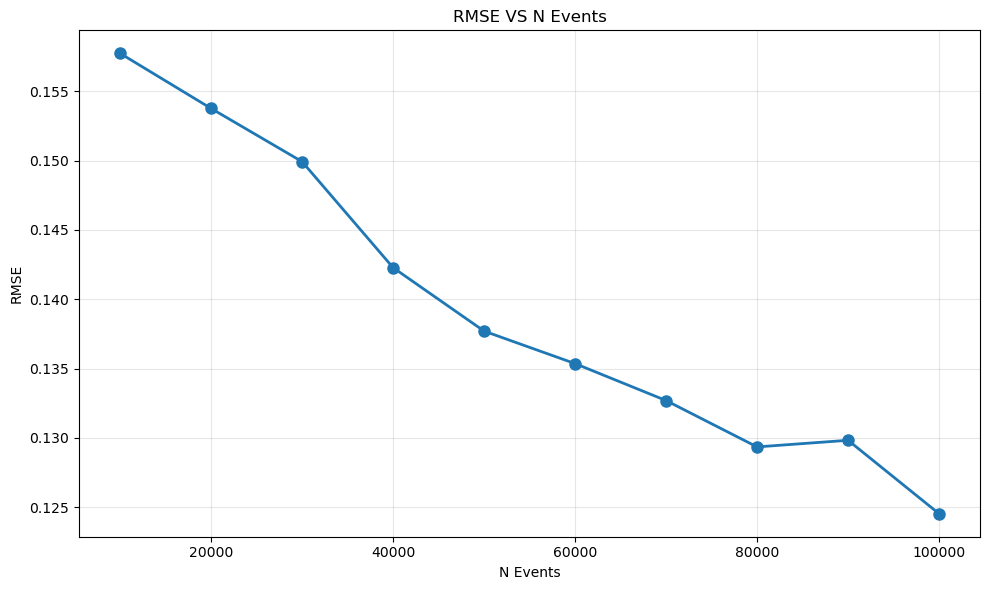

Best overall (min) W_rmse: 0.124532 | n_events=100000.0 | config=config_n100000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_n_events_seed_1",
    param_name="n_events",
    optimize="min",
    experiment_name="n_events_seed_1"
)

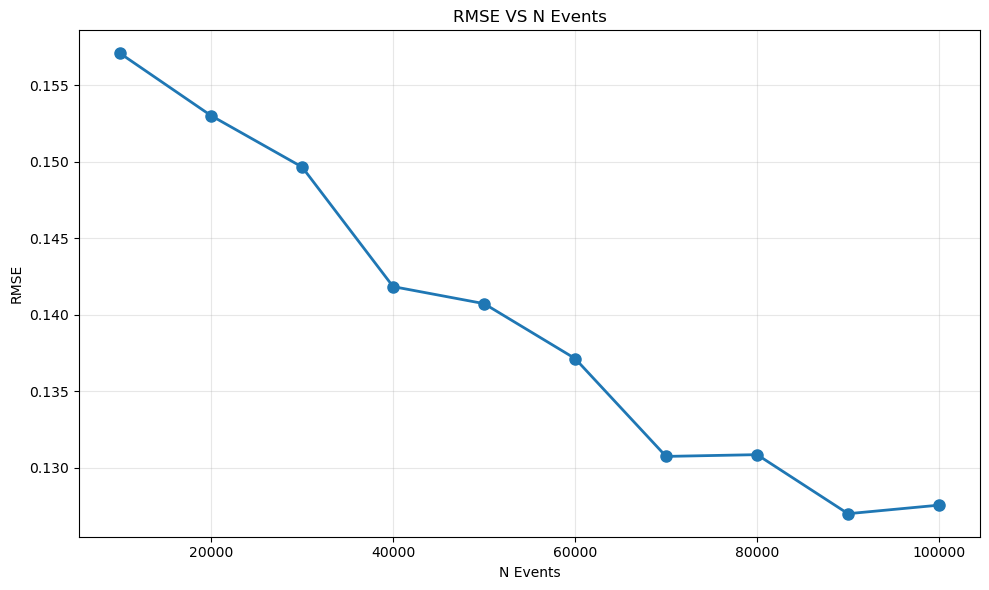

Best overall (min) W_rmse: 0.127000 | n_events=90000.0 | config=config_n90000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_n_events_seed_2",
    param_name="n_events",
    optimize="min",
    experiment_name="n_events_seed_2"
)

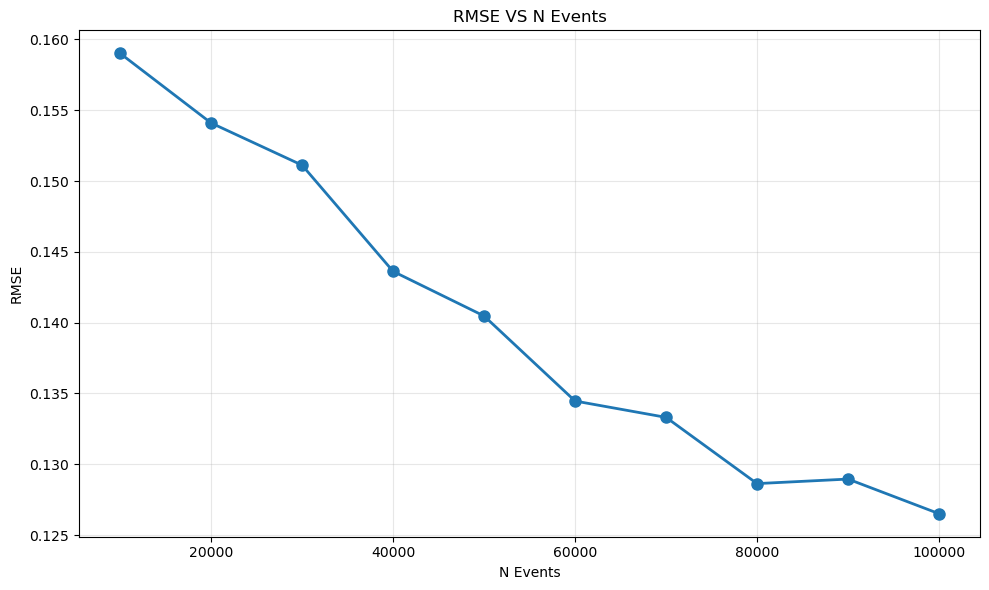

Best overall (min) W_rmse: 0.126512 | n_events=100000.0 | config=config_n100000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_n_events_seed_3",
    param_name="n_events",
    optimize="min",
    experiment_name="n_events_seed_3"
)

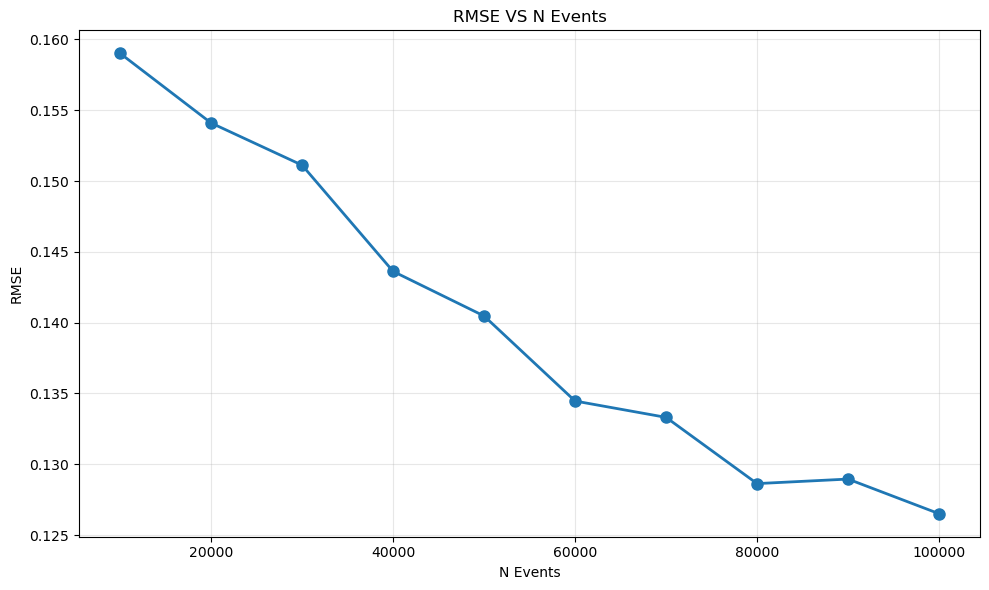

Best overall (min) W_rmse: 0.126512 | n_events=100000.0 | config=config_n100000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_n_events_seed_3",
    param_name="n_events",
    optimize="min",
    experiment_name="n_events_seed_3"
)

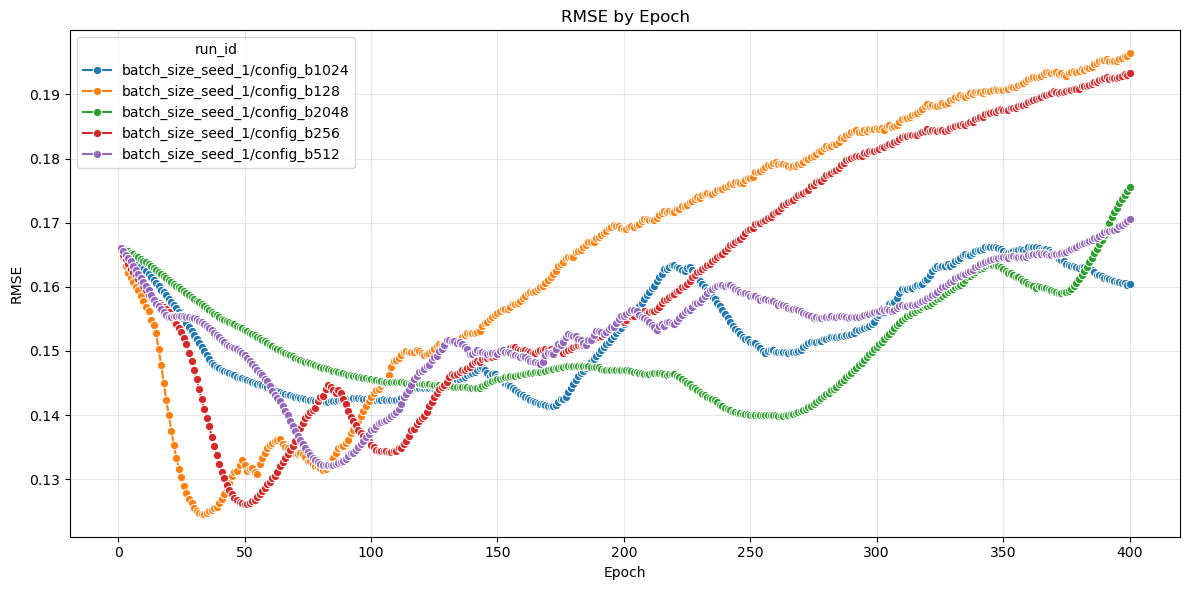

Best (min) W_rmse: 0.124637 | run=batch_size_seed_1/config_b128 | epoch=33


In [ ]:
plot_metric_by_epoch(metric="W_rmse", result_subdir="run_batch_size_seed_1", x_axis="epoch")

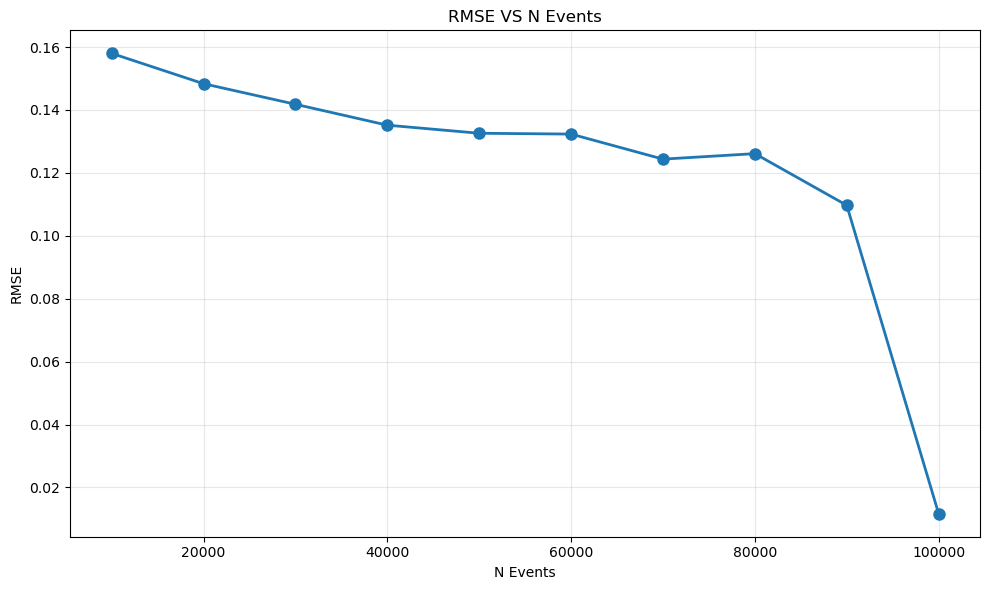

Best overall (min) W_rmse: 0.011648 | n_events=100000.0 | config=config_n100000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_wgan_2_seeds",
    param_name="n_events",
    optimize="min",
    experiment_name="wgan_2_seeds"
)

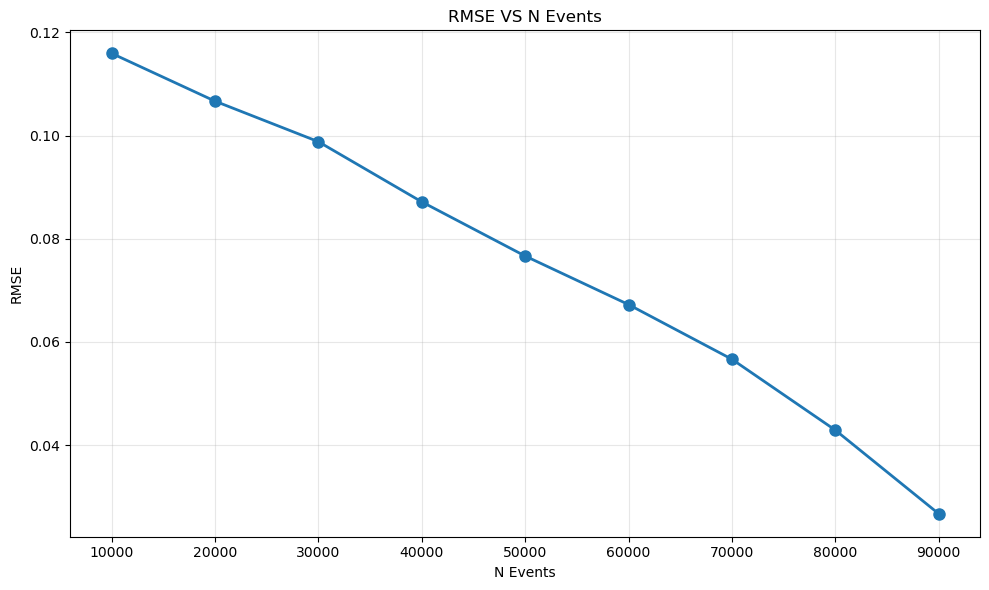

Best overall (min) W_rmse: 0.026681 | n_events=90000.0 | config=config_n90000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_ws_2_seeds",
    param_name="n_events",
    optimize="min",
    experiment_name="run_ws_2_seeds",
    exclude_param_values=[100000],
)

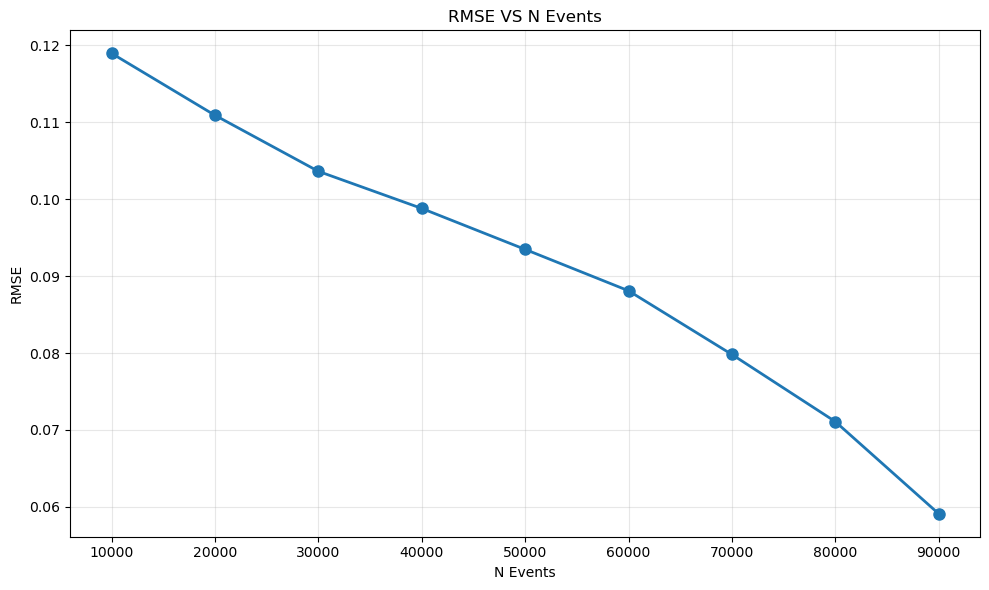

Best overall (min) W_rmse: 0.059116 | n_events=90000.0 | config=config_n90000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_ws_2_seeds_new",
    param_name="n_events",
    optimize="min",
    experiment_name="ws_2_seeds",
    exclude_param_values=[100000],
)

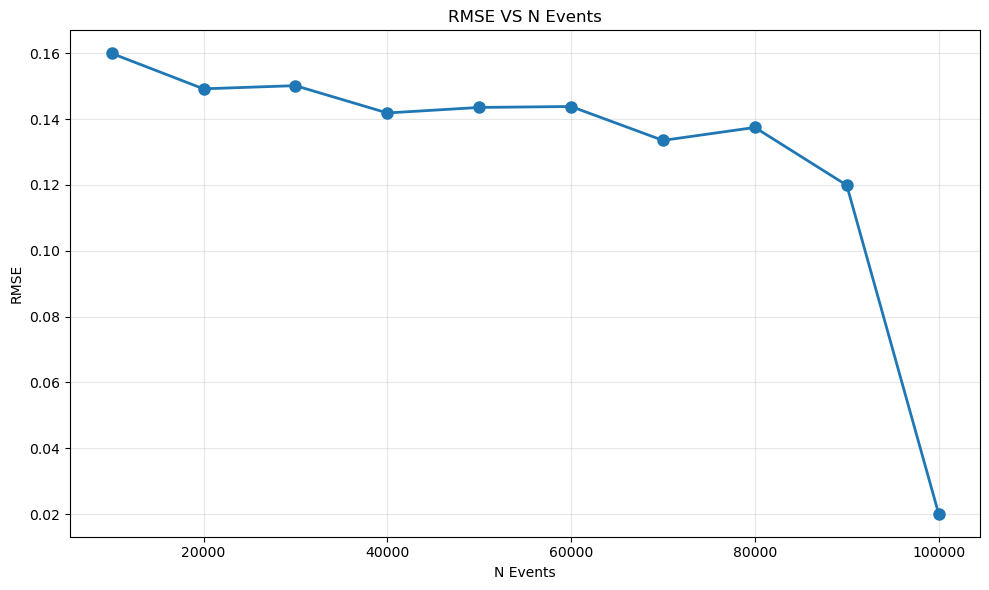

Best overall (min) W_rmse: 0.020158 | n_events=100000.0 | config=config_n100000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_wgan_2_seeds_batch_size_2048",
    param_name="n_events",
    optimize="min",
    experiment_name="wgan_2_seeds_batch_size_2048"
)

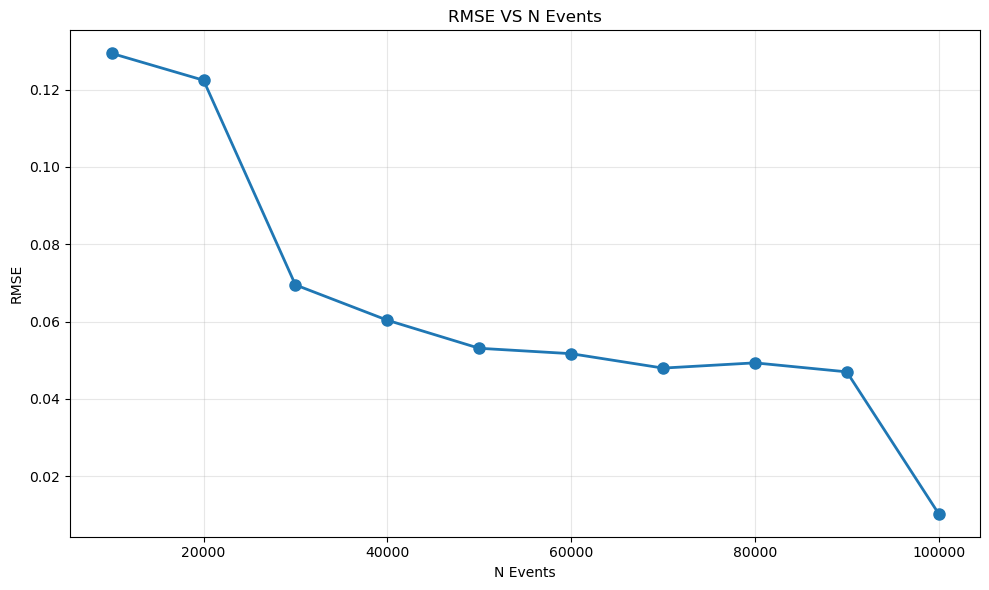

Best overall (min) W_rmse: 0.010313 | n_events=100000.0 | config=config_n100000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_wgan_2_seeds_no_energy_mask",
    param_name="n_events",
    optimize="min",
    experiment_name="wgan_2_seeds_no_energy_mask"
)

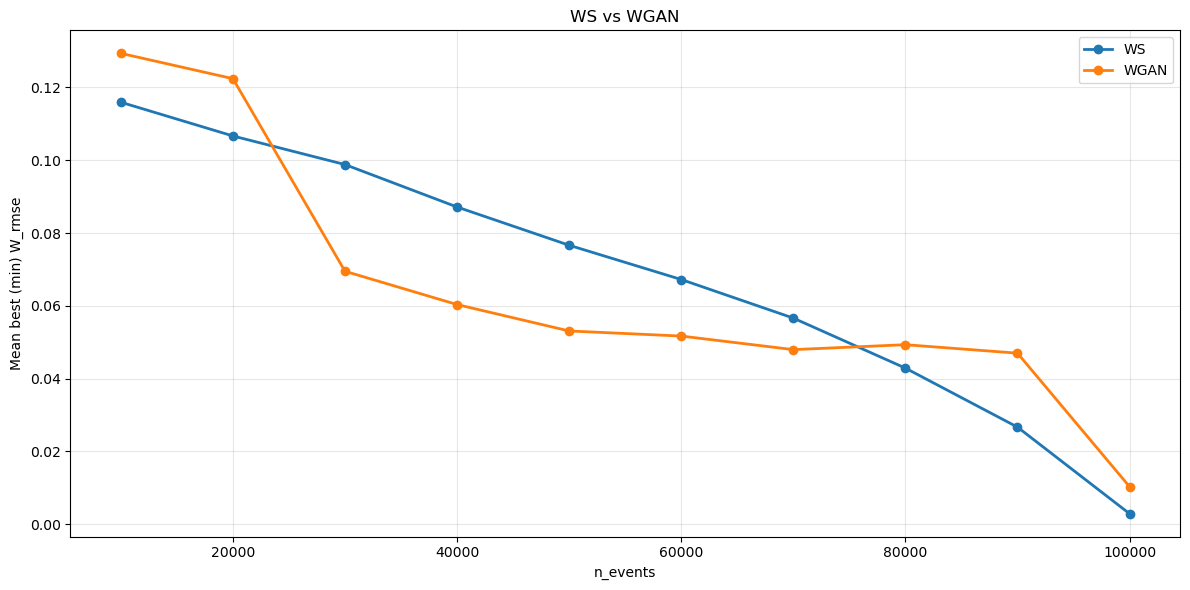

In [ ]:
import numpy as np

def _collect_best_curve(run_dir, experiment_name, metric="W_rmse", optimize="min", param_name="n_events"):
    project_root = resolve_project_root()
    base_results_dir = project_root / "results" / run_dir
    df = load_wgan_histories(base_results_dir)

    rows = []
    for config_name in df["config"].unique():
        cfg_df = df[df["config"] == config_name]
        vals = []
        for _, g in cfg_df.groupby("run_id", sort=False):
            if g.empty:
                continue
            idx = g[metric].idxmin() if optimize == "min" else g[metric].idxmax()
            vals.append(float(g.loc[idx, metric]))
        if not vals:
            continue

        config_path = resolve_project_root() / "configs" / "generated" / experiment_name / f"{config_name}.yaml"
        if not config_path.exists():
            continue
        param_value = extract_param_from_config(config_path, param_name)
        if param_value is None:
            continue

        rows.append({"param_value": float(param_value), "y": float(np.mean(vals))})

    return pd.DataFrame(rows).sort_values("param_value")

ws_df = _collect_best_curve("run_ws_2_seeds", "ws_2_seeds", metric="W_rmse", optimize="min")
wgan_df = _collect_best_curve("run_wgan_2_seeds_no_energy_mask", "wgan_2_seeds_no_energy_mask", metric="W_rmse", optimize="min")

plt.figure(figsize=(12, 6))
plt.plot(ws_df["param_value"], ws_df["y"], marker="o", linewidth=2, label="WS")
plt.plot(wgan_df["param_value"], wgan_df["y"], marker="o", linewidth=2, label="WGAN")
plt.xlabel("n_events")
plt.ylabel("Mean best (min) W_rmse")
plt.title("WS vs WGAN")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

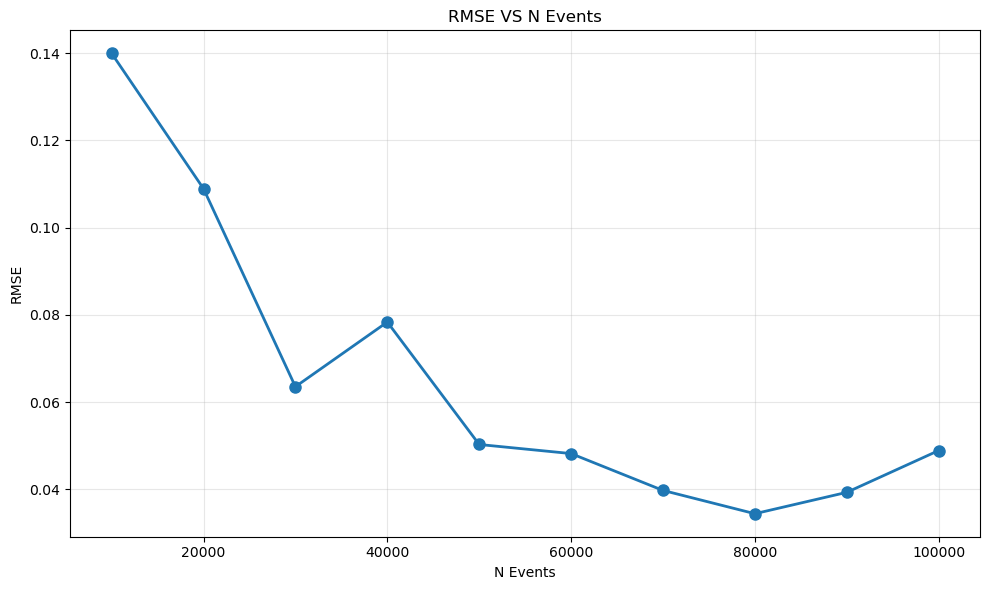

Best overall (min) W_rmse: 0.034385 | n_events=80000.0 | config=config_n80000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_wgan_2_seeds_energy_mask_batch_256_energy_cuts_epochs_50",
    param_name="n_events",
    optimize="min",
    experiment_name="wgan_2_seeds_energy_mask_batch_256_energy_cuts_epochs_50"
)

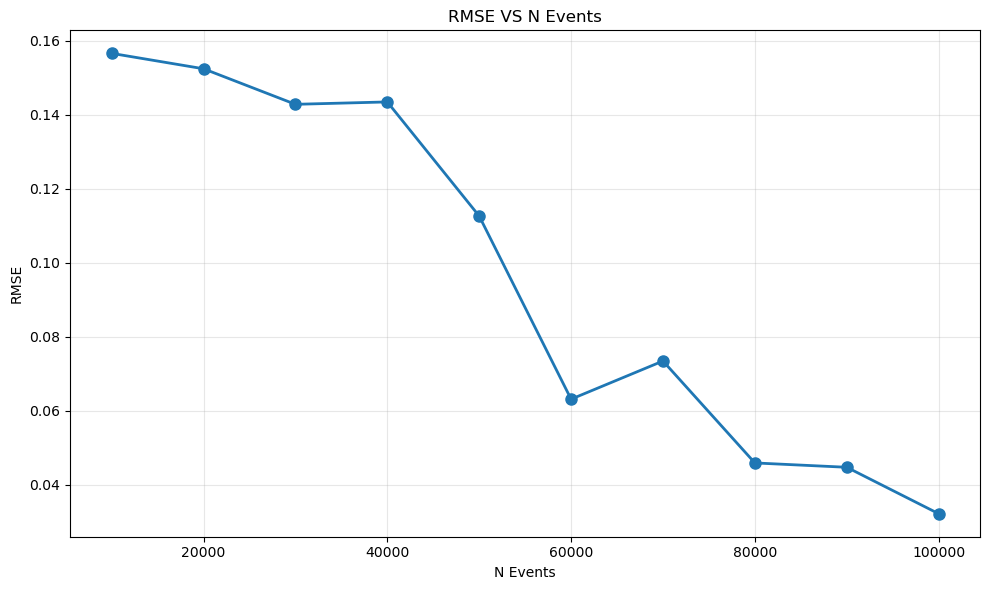

Best overall (min) W_rmse: 0.032138 | n_events=100000.0 | config=config_n100000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_wgan_2_seeds_energy_mask_batch_2048_energy_cuts_epochs_50",
    param_name="n_events",
    optimize="min",
    experiment_name="wgan_2_seeds_energy_mask_batch_2048_energy_cuts_epochs_50"
)

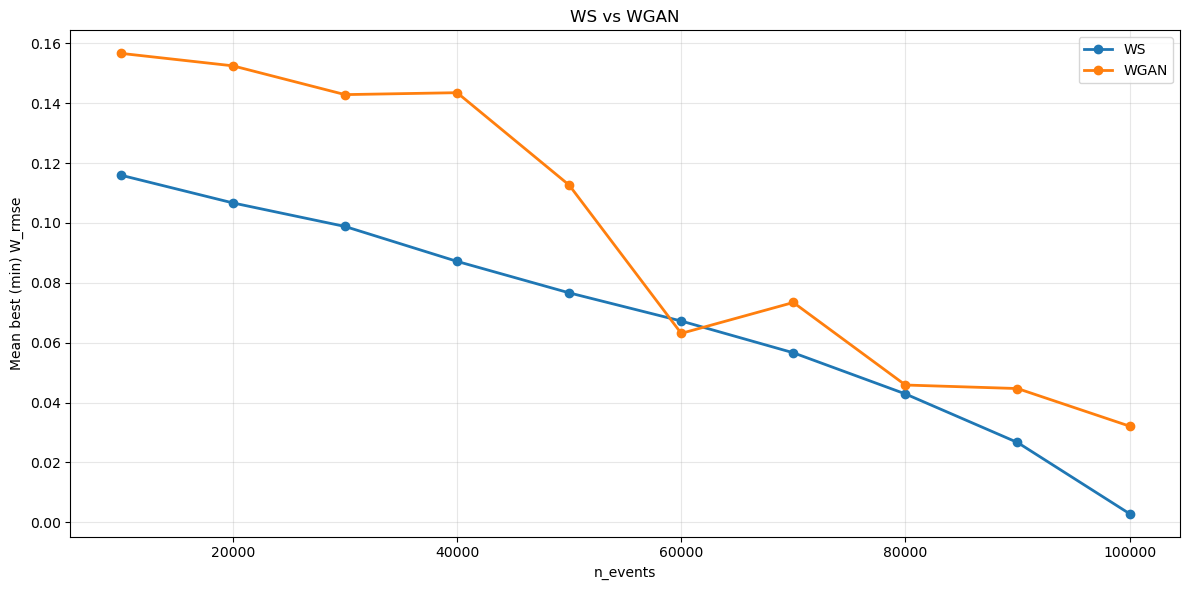

In [ ]:
ws_df = _collect_best_curve("run_ws_2_seeds", "ws_2_seeds", metric="W_rmse", optimize="min")
wgan_df = _collect_best_curve("run_wgan_2_seeds_energy_mask_batch_2048_energy_cuts_epochs_50", "wgan_2_seeds_energy_mask_batch_2048_energy_cuts_epochs_50", metric="W_rmse", optimize="min")

plt.figure(figsize=(12, 6))
plt.plot(ws_df["param_value"], ws_df["y"], marker="o", linewidth=2, label="WS")
plt.plot(wgan_df["param_value"], wgan_df["y"], marker="o", linewidth=2, label="WGAN")
plt.xlabel("n_events")
plt.ylabel("Mean best (min) W_rmse")
plt.title("WS vs WGAN")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

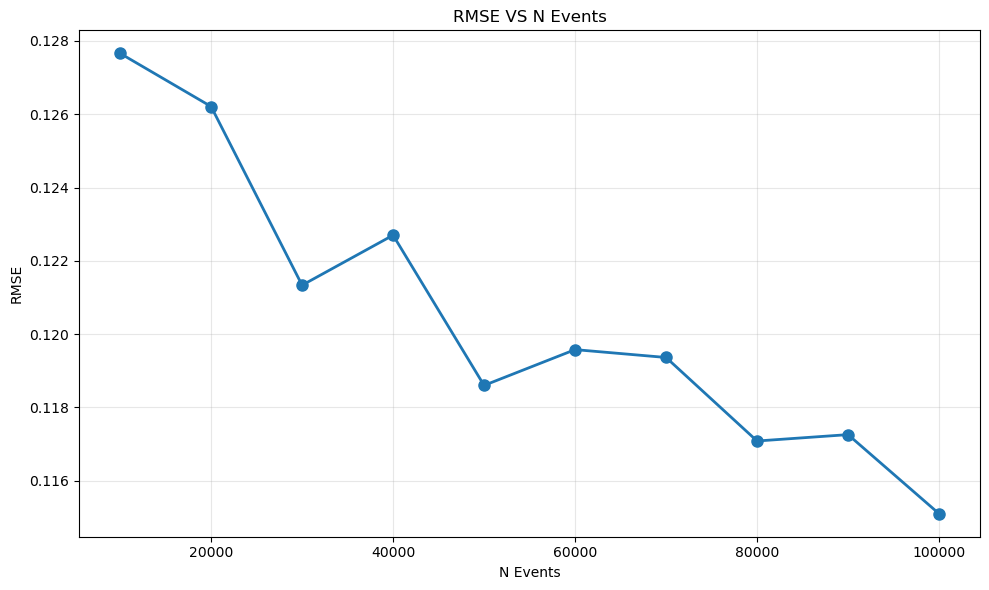

Best overall (min) W_rmse: 0.115102 | n_events=100000.0 | config=config_n100000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_ws_2_seeds_test_dataset",
    param_name="n_events",
    optimize="min",
    experiment_name="ws_2_seeds_test_dataset"
)

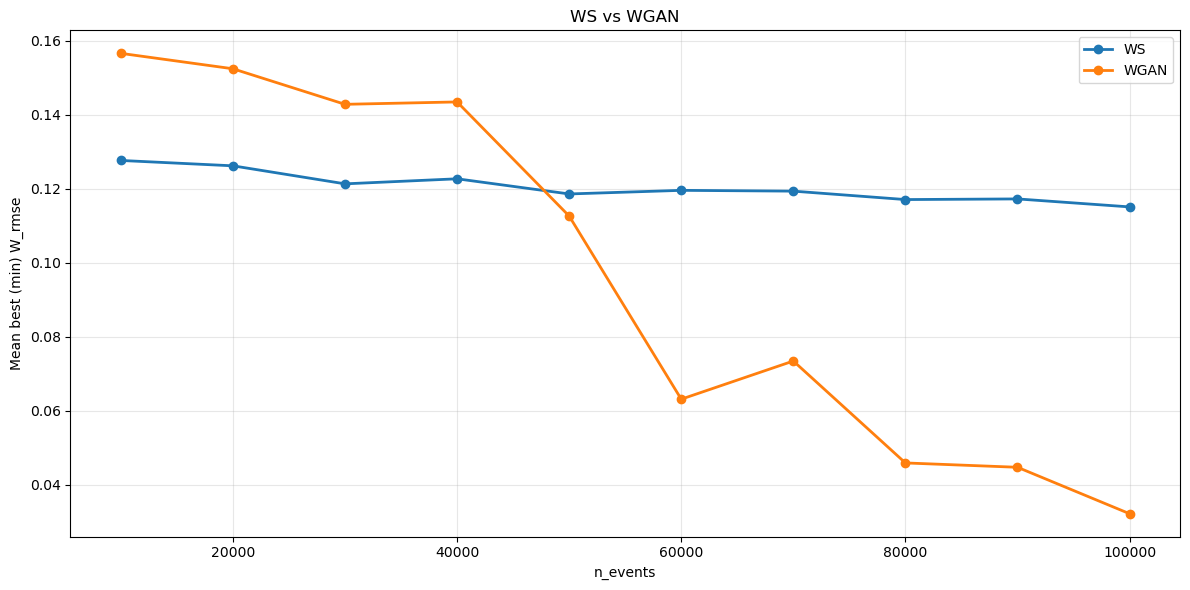

In [ ]:
ws_df = _collect_best_curve("run_ws_2_seeds_test_dataset", "ws_2_seeds_test_dataset", metric="W_rmse", optimize="min")
wgan_df = _collect_best_curve("run_wgan_2_seeds_energy_mask_batch_2048_energy_cuts_epochs_50", "wgan_2_seeds_energy_mask_batch_2048_energy_cuts_epochs_50", metric="W_rmse", optimize="min")

plt.figure(figsize=(12, 6))
plt.plot(ws_df["param_value"], ws_df["y"], marker="o", linewidth=2, label="WS")
plt.plot(wgan_df["param_value"], wgan_df["y"], marker="o", linewidth=2, label="WGAN")
plt.xlabel("n_events")
plt.ylabel("Mean best (min) W_rmse")
plt.title("WS vs WGAN")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

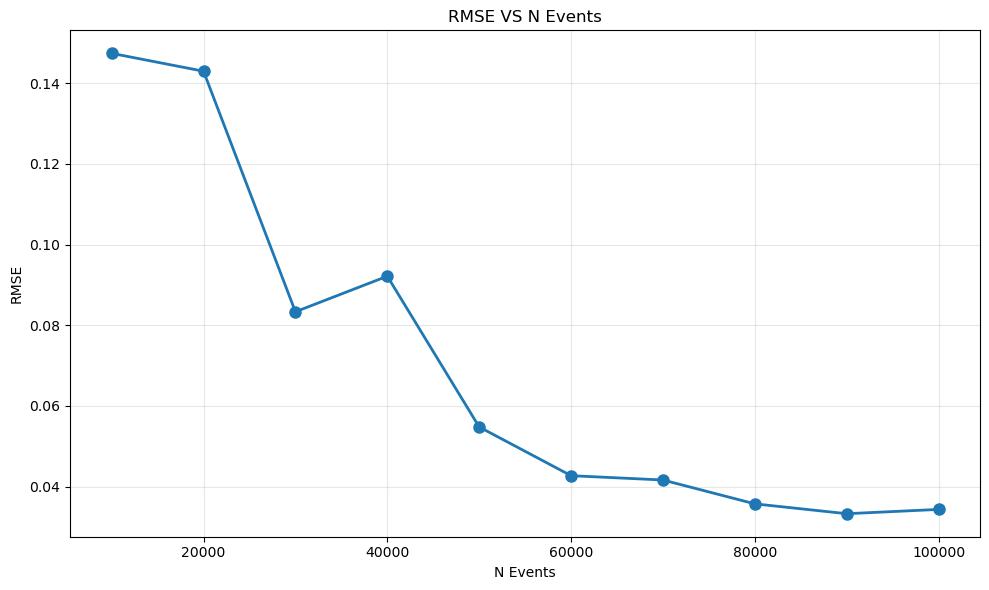

Best overall (min) W_rmse: 0.033263 | n_events=90000.0 | config=config_n90000


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_wgan_2_seeds_batch_256_scheduler_cosine",
    param_name="n_events",
    optimize="min",
    experiment_name="wgan_2_seeds_batch_256_scheduler_cosine"
)

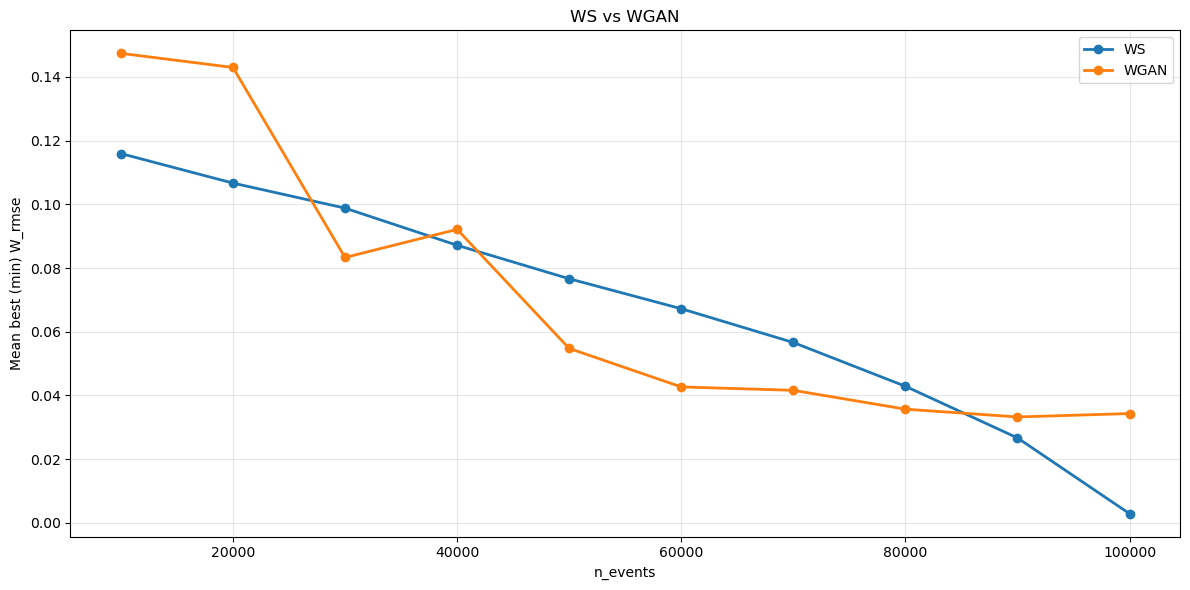

In [ ]:
ws_df = _collect_best_curve("run_ws_2_seeds", "ws_2_seeds", metric="W_rmse", optimize="min")
wgan_df = _collect_best_curve("run_wgan_2_seeds_batch_256_scheduler_cosine", "wgan_2_seeds_batch_256_scheduler_cosine", metric="W_rmse", optimize="min")

plt.figure(figsize=(12, 6))
plt.plot(ws_df["param_value"], ws_df["y"], marker="o", linewidth=2, label="WS")
plt.plot(wgan_df["param_value"], wgan_df["y"], marker="o", linewidth=2, label="WGAN")
plt.xlabel("n_events")
plt.ylabel("Mean best (min) W_rmse")
plt.title("WS vs WGAN")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

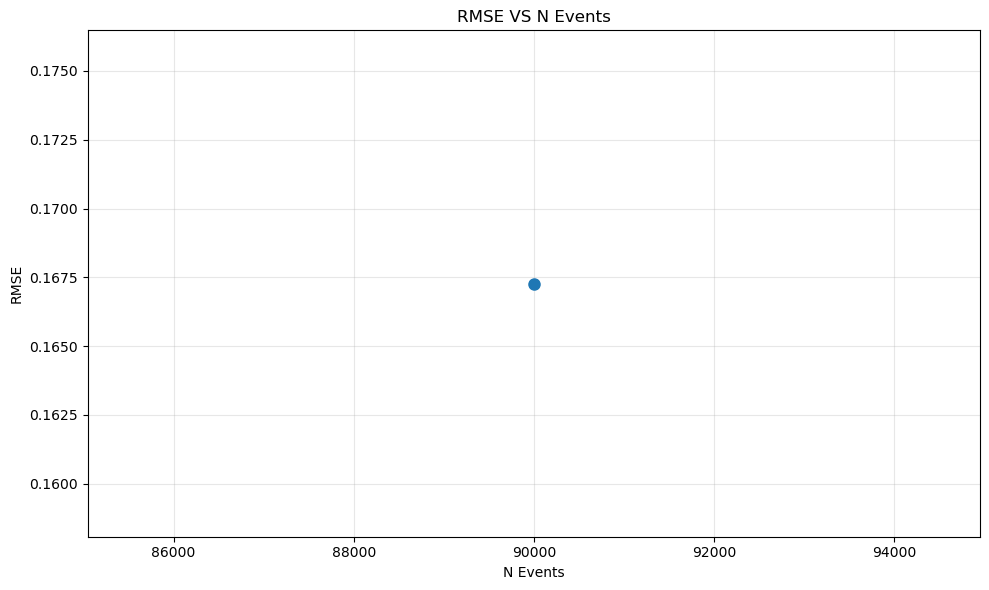

Best overall (min) W_rmse: 0.167275 | n_events=90000.0 | config=config


In [ ]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_wgan_90k_events",
    param_name="n_events",
    optimize="min",
    experiment_name="wgan_90k_events"
)

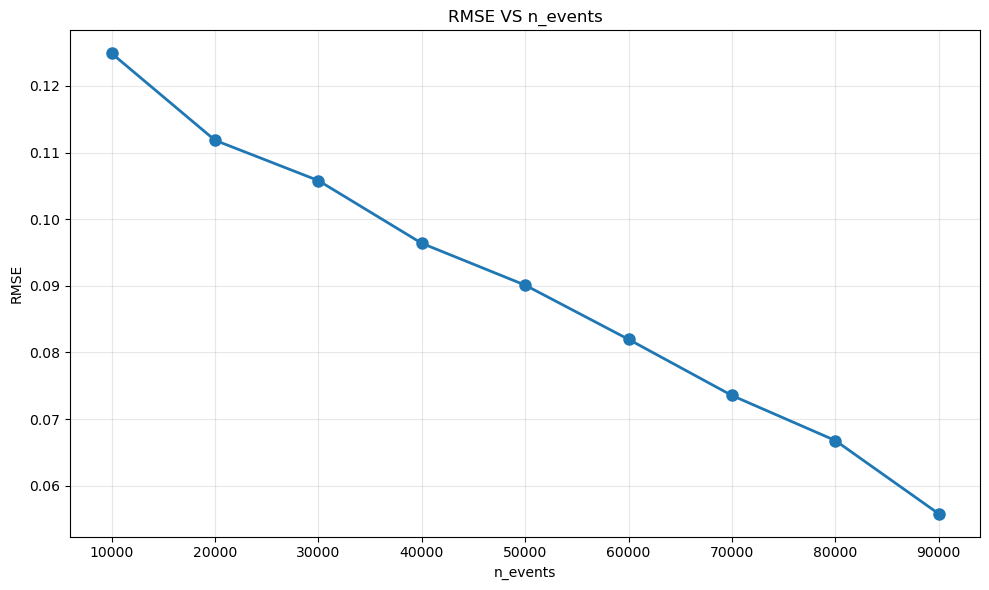

Best overall (min) W_rmse: 0.055802 | n_events=90000.0 | config=config_n90000


In [3]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_ws_final",
    param_name="n_events",
    optimize="min",
    experiment_name="ws_final"
)

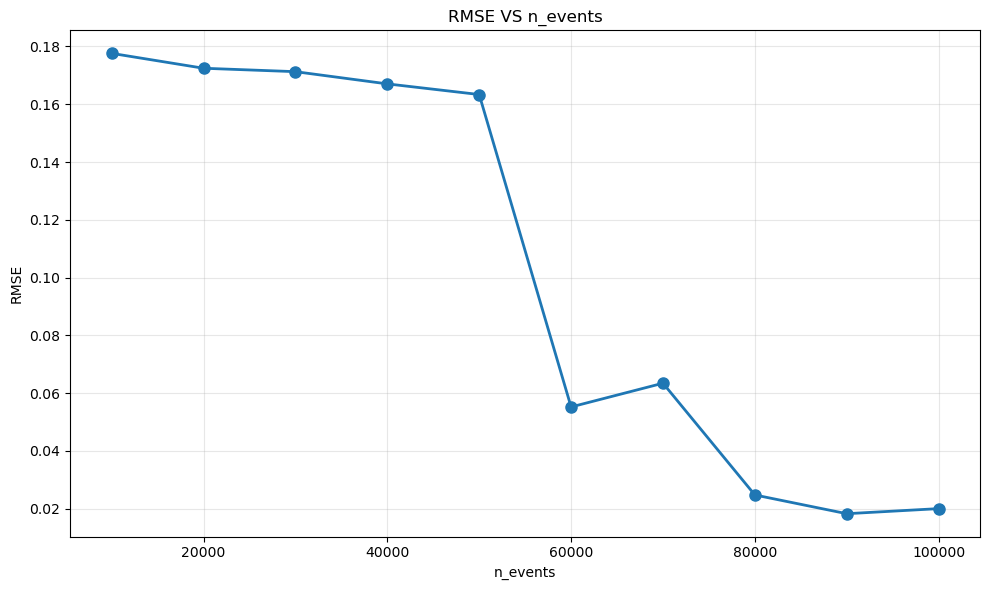

Best overall (min) W_rmse: 0.018291 | n_events=90000.0 | config=config_n90000


In [4]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_wgan_n_critic_5_epochs_200_n_events",
    param_name="n_events",
    optimize="min",
    experiment_name="wgan_n_critic_5_epochs_200_n_events"
)

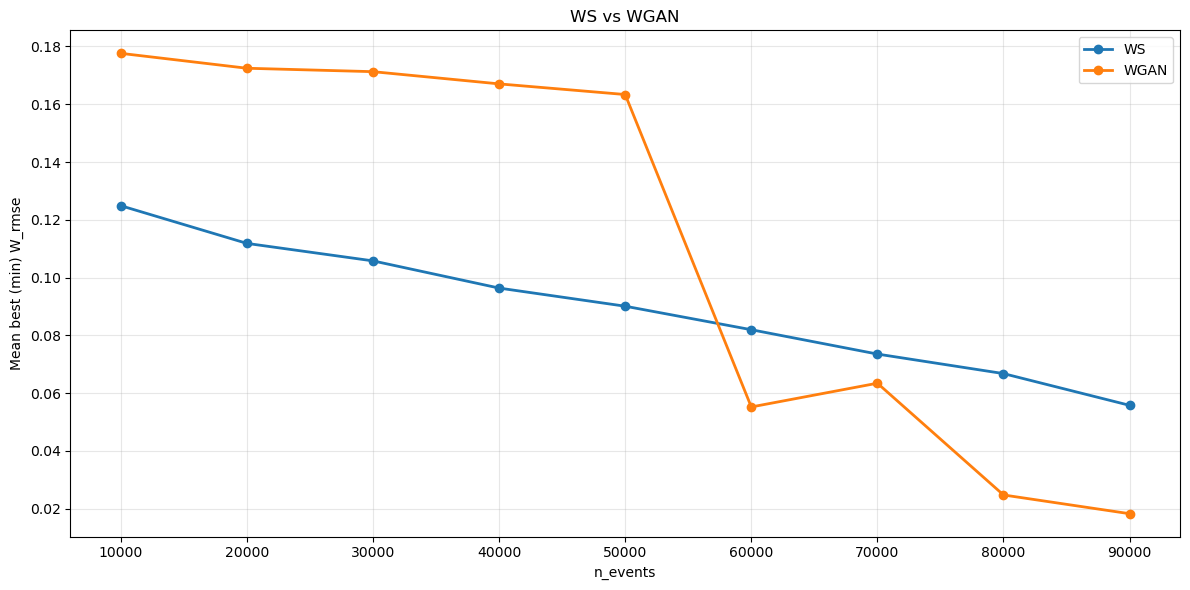

In [15]:
import numpy as np

def _collect_best_curve(run_dir, experiment_name, metric="W_rmse", optimize="min", param_name="n_events"):
    project_root = resolve_project_root()
    base_results_dir = project_root / "results" / run_dir
    df = load_wgan_histories(base_results_dir)

    rows = []
    for config_name in df["config"].unique():
        cfg_df = df[df["config"] == config_name]
        vals = []
        for _, g in cfg_df.groupby("run_id", sort=False):
            if g.empty:
                continue
            idx = g[metric].idxmin() if optimize == "min" else g[metric].idxmax()
            vals.append(float(g.loc[idx, metric]))
        if not vals:
            continue

        config_path = resolve_project_root() / "configs" / "generated" / experiment_name / f"{config_name}.yaml"
        if not config_path.exists():
            continue
        param_value = extract_param_from_config(config_path, param_name)
        if param_value is None:
            continue

        rows.append({"param_value": float(param_value), "y": float(np.mean(vals))})

    return pd.DataFrame(rows).sort_values("param_value")

ws_df = _collect_best_curve("run_ws_final", "ws_final", metric="W_rmse", optimize="min")
wgan_df = _collect_best_curve("run_wgan_n_critic_5_epochs_200_n_events", "wgan_n_critic_5_epochs_200_n_events", metric="W_rmse", optimize="min")

plt.figure(figsize=(12, 6))
plt.plot(ws_df["param_value"], ws_df["y"], marker="o", linewidth=2, label="WS")
plt.plot(wgan_df["param_value"], wgan_df["y"], marker="o", linewidth=2, label="WGAN")
plt.xlabel("n_events")
plt.ylabel("Mean best (min) W_rmse")
plt.title("WS vs WGAN")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

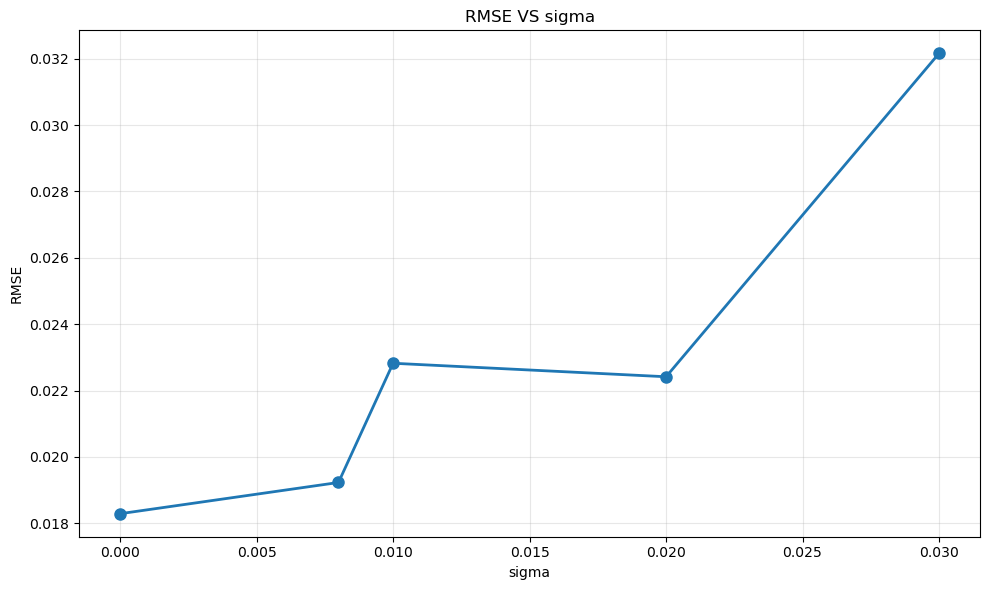

Best overall (min) W_rmse: 0.019232 | sigma=0.008 | config=config_sigma0p008


In [14]:
import math

_baseline_csv = (
    resolve_project_root()
    / "results/run_wgan_n_critic_5_epochs_200_n_events"
    / "wgan_n_critic_5_epochs_200_n_events/config_n90000/wgan_predictions.csv"
)
_df_baseline = pd.read_csv(_baseline_csv)
_baseline_rmse = math.sqrt((((_df_baseline["a_true"] - _df_baseline["a_pred"]) ** 2).mean()))

plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_wgan_noise",
    param_name="sigma",
    optimize="min",
    experiment_name="wgan_noise",
    baseline_point=(0.0, _baseline_rmse),
)